# Sign Language Classification
### CNN vs MLP vs Transfer Learning

---

## Dataset Labels

Each image is assigned to one of the following labels (A–Z, excluding J and Z which require motion):

| Index | Letter | Index | Letter | Index | Letter |
|-------|--------|-------|--------|-------|--------|
| 0 | A | 9 | K | 18 | T |
| 1 | B | 10 | L | 19 | U |
| 2 | C | 11 | M | 20 | V |
| 3 | D | 12 | N | 21 | W |
| 4 | E | 13 | O | 22 | X |
| 5 | F | 14 | P | 23 | Y |
| 6 | G | 15 | Q | 24 | Z |
| 7 | H | 16 | R | | |
| 8 | I | 17 | S | | |

> **Note:** Letter J is excluded because it requires a motion gesture.

---
## 1. Import Libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelBinarizer
import os
print(os.listdir('/kaggle/input/datasets/mimoali404/sign-language-mnist'))

['sign_mnist_test.csv', 'sign_mnist_train.csv']


---
## 2. Load Dataset

In [44]:
train_df = pd.read_csv('/kaggle/input/datasets/mimoali404/sign-language-mnist/sign_mnist_train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/mimoali404/sign-language-mnist/sign_mnist_test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (27455, 785)
Test shape:  (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


---
## 3. Exploratory Data Analysis

In [45]:
train_labels = train_df['label'].values
test_labels  = test_df['label'].values

train_images = train_df.drop('label', axis=1).values
test_images  = test_df.drop('label', axis=1).values

print('Unique classes:', np.unique(train_labels))
print('Train images shape:', train_images.shape)
print('Test images shape: ', test_images.shape)

Unique classes: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Train images shape: (27455, 784)
Test images shape:  (7172, 784)


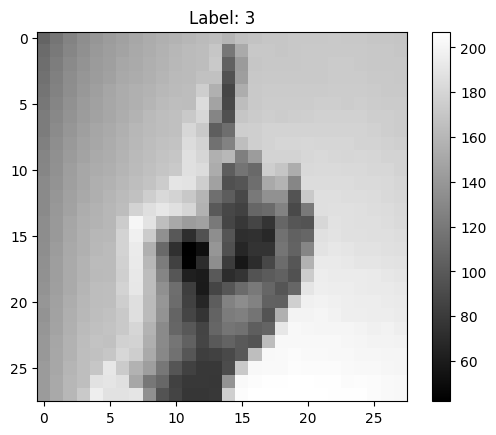

In [46]:
# Draw first image
plt.imshow(train_images[0].reshape(28, 28), cmap='gray')
plt.colorbar()
plt.title(f'Label: {train_labels[0]}')
plt.show()

---
## 4. Data Preprocessing

- **Step 1** — Normalize pixel values to [0, 1]
- **Step 2** — Reshape from flat (784,) to (28, 28, 1) for CNN input
- **Step 3** — One-hot encode labels

In [47]:
# Normalization
train_images = train_images / 255.0
test_images  = test_images  / 255.0

# Reshape --> (samples, 28, 28, 1)
train_images = train_images.reshape(-1, 28, 28, 1)
test_images  = test_images.reshape(-1, 28, 28, 1)

print('Train images shape after reshape:', train_images.shape)
print('Test images shape after reshape: ', test_images.shape)

# One-hot encode labels
lb = LabelBinarizer()
train_labels_ohe = lb.fit_transform(train_labels)
test_labels_ohe  = lb.transform(test_labels)

num_classes = train_labels_ohe.shape[1]
print('Number of classes:', num_classes)

Train images shape after reshape: (27455, 28, 28, 1)
Test images shape after reshape:  (7172, 28, 28, 1)
Number of classes: 24


Letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Count:   24


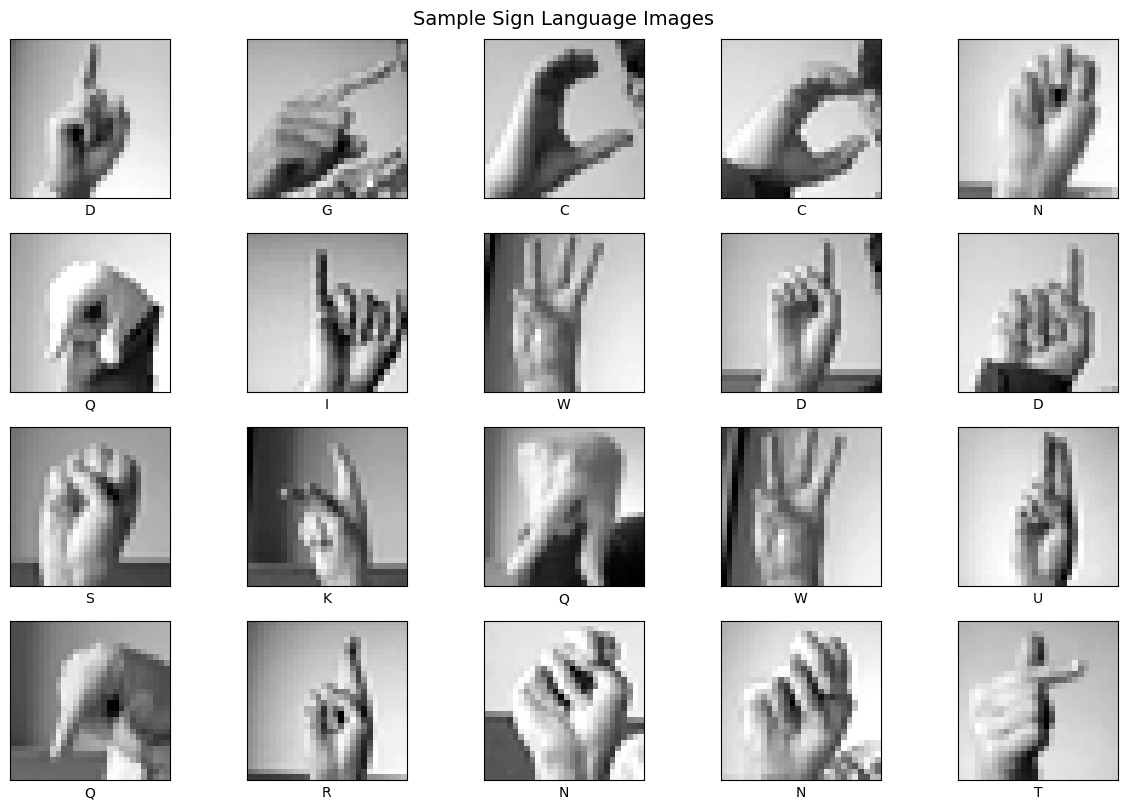

In [48]:
# Dynamically build label map from actual data
unique_labels = sorted(np.unique(np.concatenate([train_labels, test_labels])))
all_letters   = 'ABCDEFGHIKLMNOPQRSTUVWXYZ'  # 25 letters (no J)
label_map     = {label: all_letters[i] for i, label in enumerate(unique_labels)}
letters       = [label_map[l] for l in unique_labels]

print('Letters:', letters)
print('Count:  ', len(letters))

# Show sample images
plt.figure(figsize=(12, 10))
for i in range(20):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.xlabel(label_map[train_labels[i]])
plt.suptitle('Sample Sign Language Images', fontsize=14)
plt.tight_layout()
plt.show()


## 5. CNN Model


In [49]:
model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,904 (1.51 MB)

 Trainable params: 394,456 (1.50 MB)

 Non-trainable params: 448 (1.75 KB)

In [50]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Data Augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)

# Callbacks
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [51]:
history = model.fit(
    datagen.flow(train_images, train_labels_ohe, batch_size=64),
    epochs=15,
    validation_data=(test_images, test_labels_ohe),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


429/429 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.2505 - loss: 2.6932 - val_accuracy: 0.4371 - val_loss: 2.0580 - learning_rate: 0.0010
Epoch 2/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7392 - loss: 0.7546 - val_accuracy: 0.8707 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 3/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8682 - loss: 0.3867 - val_accuracy: 0.9387 - val_loss: 0.1459 - learning_rate: 0.0010
Epoch 4/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9139 - loss: 0.2515 - val_accuracy: 0.9837 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 5/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9343 - loss: 0.1937 - val_accuracy: 0.9933 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 6/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9499 - loss: 0.1503 - val_accuracy: 0.9269 - val_loss: 0.1815 - learning_rate: 0.0010
Epoch 7/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9559 - loss: 0.1330

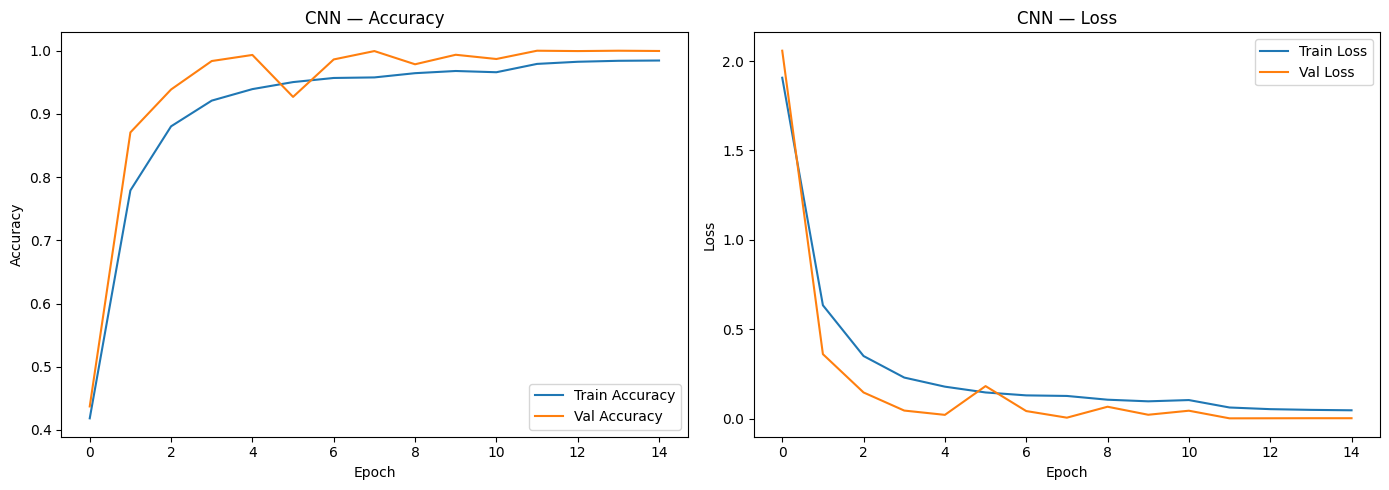

In [52]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [53]:
# Evaluation
cnn_loss, cnn_acc = model.evaluate(test_images, test_labels_ohe)
print(f'CNN Test Loss:     {cnn_loss:.4f}')
print(f'CNN Test Accuracy: {cnn_acc:.4f}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0011
CNN Test Loss:     0.0012
CNN Test Accuracy: 1.0000


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


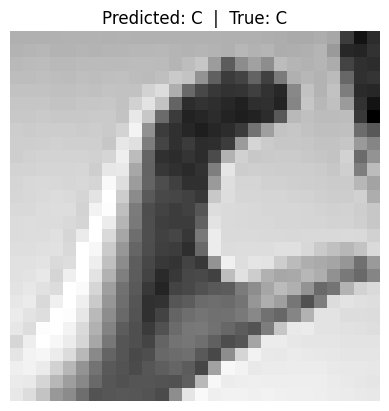

In [54]:
# Predictions on a sample image
predictions    = model.predict(test_images)
y_pred_indices = np.argmax(predictions, axis=1)
y_pred         = lb.classes_[y_pred_indices]

sample_idx      = 20
predicted_class = y_pred[sample_idx]
true_class      = test_labels[sample_idx]

plt.imshow(test_images[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f'Predicted: {label_map[predicted_class]}  |  True: {label_map[true_class]}')
plt.axis('off'); plt.show()

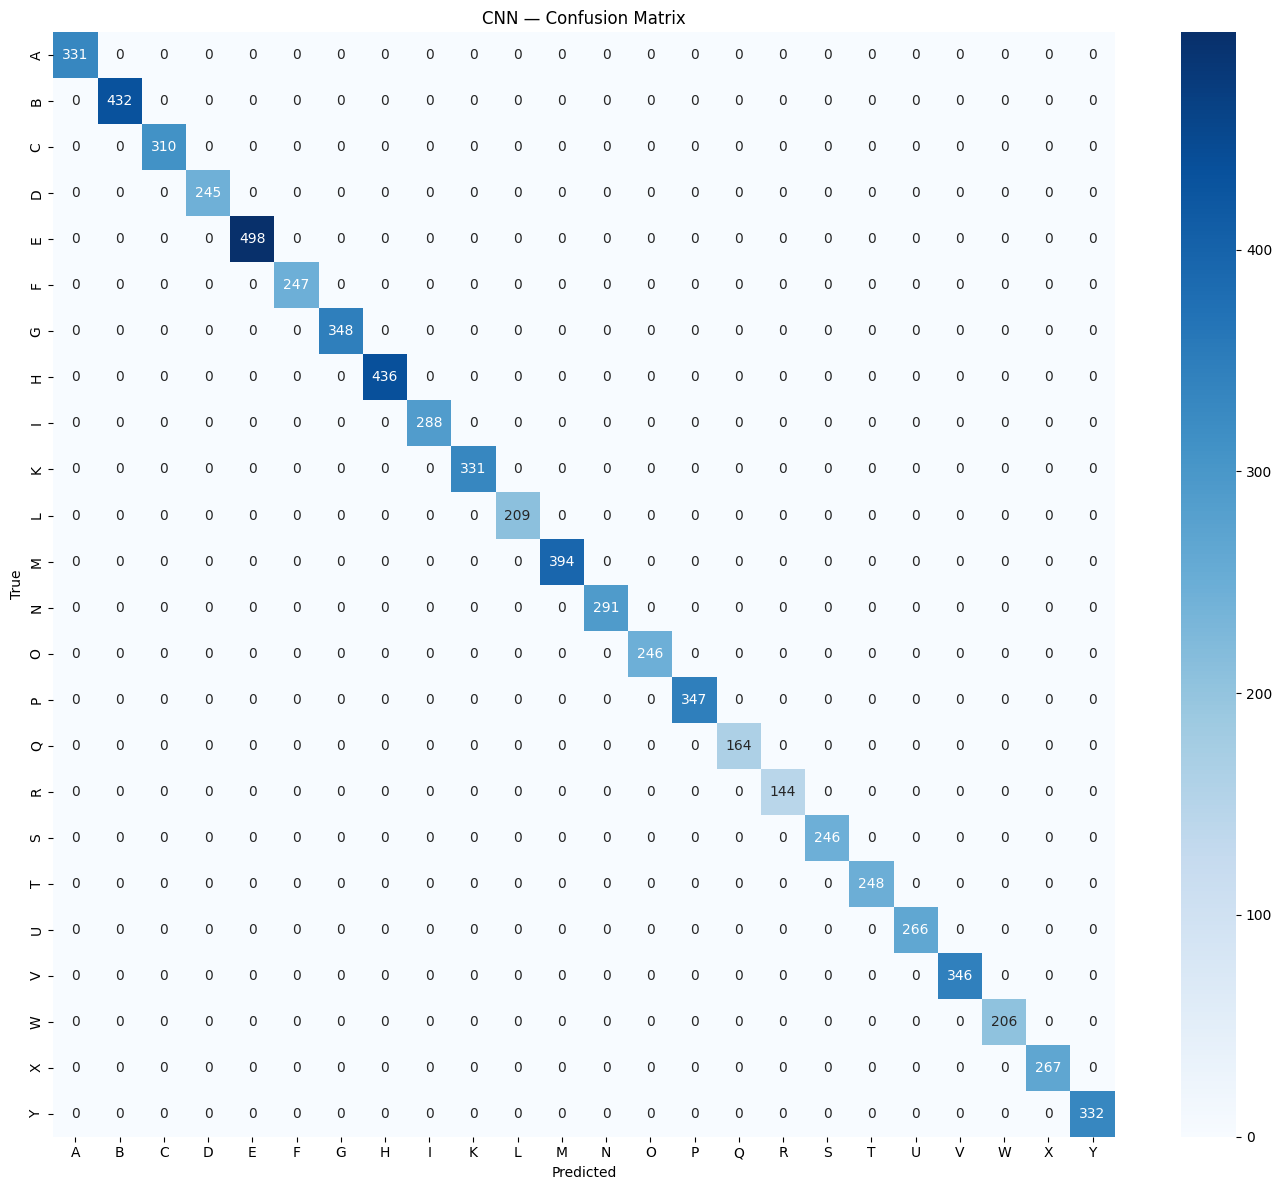

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00       144
           S       1.00    

In [55]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=letters, yticklabels=letters)
plt.title('CNN — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print(classification_report(test_labels, y_pred, target_names=letters))

### CNN — Test Image Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step


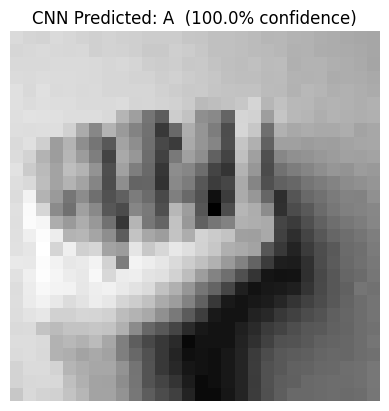

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


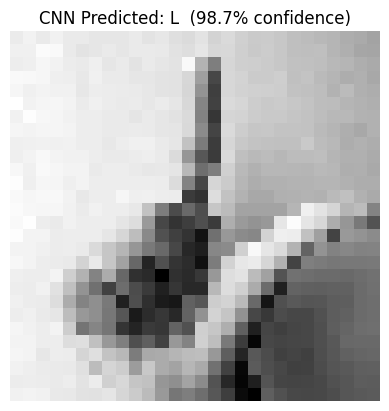

In [56]:
def predict_image_cnn(img_path):
    img       = tf.io.read_file(img_path)
    img       = tf.image.decode_image(img, channels=1)
    img       = tf.image.resize(img, [28, 28])
    img_array = img.numpy() / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    pred      = model.predict(img_array)
    letter    = label_map[lb.classes_[np.argmax(pred)]]
    conf      = np.max(pred) * 100
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f'CNN Predicted: {letter}  ({conf:.1f}% confidence)')
    plt.axis('off'); plt.show()

predict_image_cnn('/kaggle/input/datasets/mimoali404/test-image/testproject.png')
predict_image_cnn('/kaggle/input/datasets/mimoali404/test-image3/testproject2.png')


## 6. MLP Model


In [57]:
mlp_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,240 (2.17 MB)

 Trainable params: 569,240 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
mlp_early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
mlp_reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [59]:
mlp_history = mlp_model.fit(
    train_images, train_labels_ohe,
    epochs=15,
    batch_size=64,
    validation_data=(test_images, test_labels_ohe),
    callbacks=[mlp_early_stop, mlp_reduce_lr]
)

Epoch 1/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0863 - loss: 3.0448 - val_accuracy: 0.3625 - val_loss: 1.9819 - learning_rate: 0.0010
Epoch 2/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2947 - loss: 2.0579 - val_accuracy: 0.4239 - val_loss: 1.6955 - learning_rate: 0.0010
Epoch 3/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3865 - loss: 1.7515 - val_accuracy: 0.4529 - val_loss: 1.5734 - learning_rate: 0.0010
Epoch 4/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4270 - loss: 1.6184 - val_accuracy: 0.5297 - val_loss: 1.3926 - learning_rate: 0.0010
Epoch 5/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4896 - loss: 1.4530 - val_accuracy: 0.5551 - val_loss: 1.3007 - learning_rate: 0.0010
Epoch 6/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5354 - loss: 1.3344 - val_accuracy: 0.5954 - val_loss: 1.2223 - learning_rate: 0.0010
Epoch 7/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5623 - loss: 1.2526 -

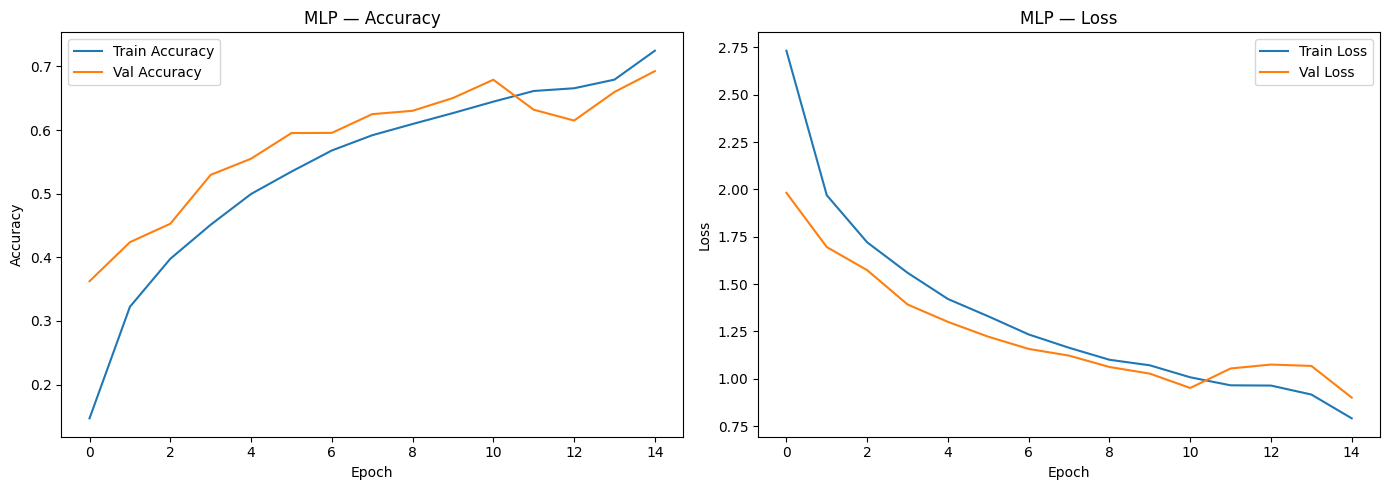

In [60]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mlp_history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(mlp_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('MLP — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(mlp_history.history['loss'],     label='Train Loss')
axes[1].plot(mlp_history.history['val_loss'], label='Val Loss')
axes[1].set_title('MLP — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [61]:
# Evaluation
mlp_loss, mlp_acc = mlp_model.evaluate(test_images, test_labels_ohe)
print(f'MLP Test Loss:     {mlp_loss:.4f}')
print(f'MLP Test Accuracy: {mlp_acc:.4f}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6894 - loss: 0.9053
MLP Test Loss:     0.9009
MLP Test Accuracy: 0.6927


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


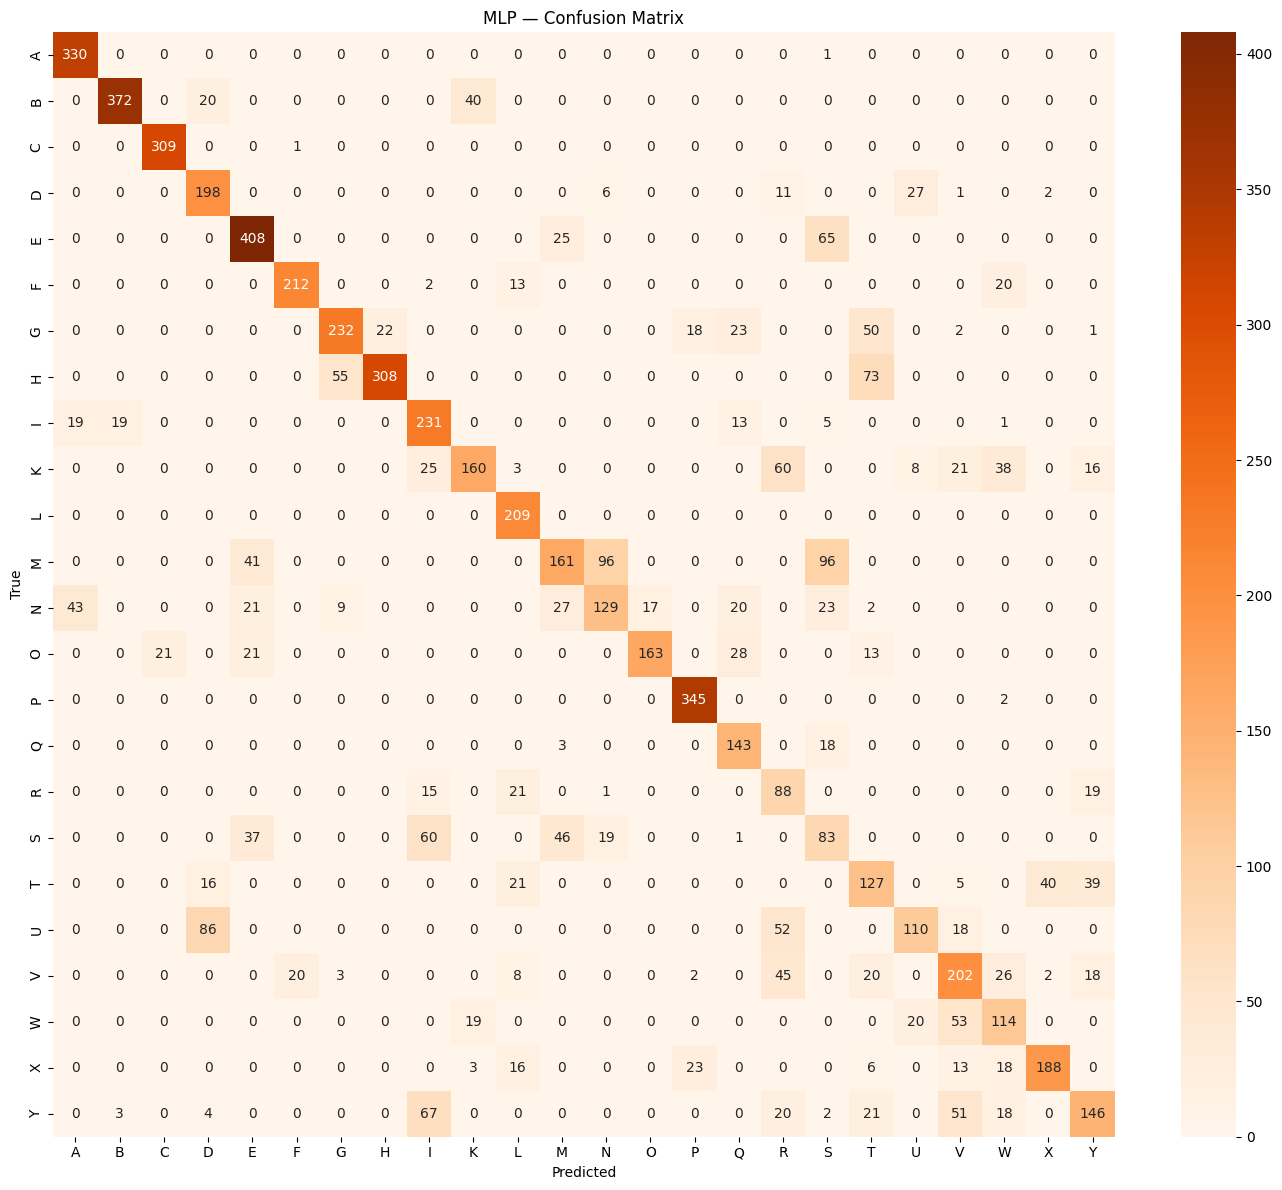

              precision    recall  f1-score   support

           A       0.84      1.00      0.91       331
           B       0.94      0.86      0.90       432
           C       0.94      1.00      0.97       310
           D       0.61      0.81      0.70       245
           E       0.77      0.82      0.80       498
           F       0.91      0.86      0.88       247
           G       0.78      0.67      0.72       348
           H       0.93      0.71      0.80       436
           I       0.58      0.80      0.67       288
           K       0.72      0.48      0.58       331
           L       0.72      1.00      0.84       209
           M       0.61      0.41      0.49       394
           N       0.51      0.44      0.48       291
           O       0.91      0.66      0.77       246
           P       0.89      0.99      0.94       347
           Q       0.63      0.87      0.73       164
           R       0.32      0.61      0.42       144
           S       0.28    

In [62]:
# Confusion Matrix
mlp_predictions  = mlp_model.predict(test_images)
mlp_pred_indices = np.argmax(mlp_predictions, axis=1)
mlp_y_pred       = lb.classes_[mlp_pred_indices]

cm_mlp = confusion_matrix(test_labels, mlp_y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', xticklabels=letters, yticklabels=letters)
plt.title('MLP — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print(classification_report(test_labels, mlp_y_pred, target_names=letters))

### MLP — Test Image Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


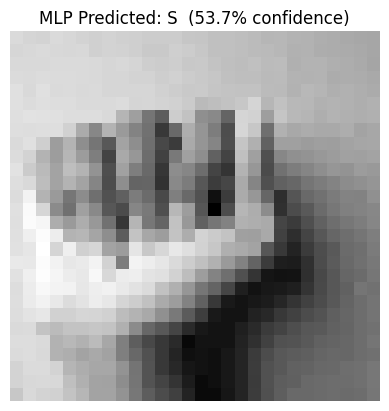

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


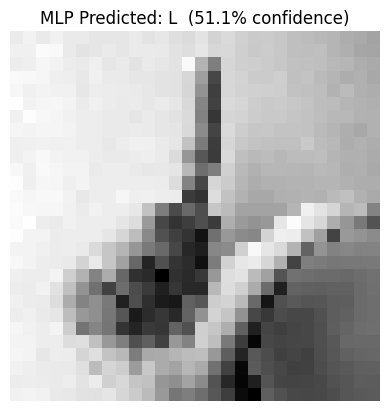

In [63]:
def predict_image_mlp(img_path):
    img       = tf.io.read_file(img_path)
    img       = tf.image.decode_image(img, channels=1)
    img       = tf.image.resize(img, [28, 28])
    img_array = img.numpy() / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    pred      = mlp_model.predict(img_array)
    letter    = label_map[lb.classes_[np.argmax(pred)]]
    conf      = np.max(pred) * 100
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f'MLP Predicted: {letter}  ({conf:.1f}% confidence)')
    plt.axis('off'); plt.show()

predict_image_mlp('/kaggle/input/datasets/mimoali404/test-image/testproject.png')
predict_image_mlp('/kaggle/input/datasets/mimoali404/test-image3/testproject2.png')


## 7. Transfer Learning — MobileNetV2


In [64]:
IMG_SIZE_TL = 96

# Resize and convert grayscale → RGB
train_images_tl = np.repeat(
    tf.image.resize(train_images, [IMG_SIZE_TL, IMG_SIZE_TL]).numpy(), 3, axis=-1
)
test_images_tl = np.repeat(
    tf.image.resize(test_images, [IMG_SIZE_TL, IMG_SIZE_TL]).numpy(), 3, axis=-1
)

print('Train shape for TL:', train_images_tl.shape)
print('Test shape for TL: ', test_images_tl.shape)

Train shape for TL: (27455, 96, 96, 3)
Test shape for TL:  (7172, 96, 96, 3)


In [65]:
# Load pretrained base
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Build model
tl_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [66]:
tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
tl_early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
tl_reduce_lr  = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [67]:
tl_history = tl_model.fit(
    train_images_tl, train_labels_ohe,
    epochs=15,
    batch_size=64,
    validation_data=(test_images_tl, test_labels_ohe),
    callbacks=[tl_early_stop, tl_reduce_lr]
)

Epoch 1/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.6724 - loss: 1.1175 - val_accuracy: 0.9697 - val_loss: 0.1210 - learning_rate: 0.0010
Epoch 2/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9735 - loss: 0.1057 - val_accuracy: 0.9788 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 3/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9869 - loss: 0.0542 - val_accuracy: 0.9816 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 4/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9922 - loss: 0.0337 - val_accuracy: 0.9771 - val_loss: 0.0611 - learning_rate: 0.0010
Epoch 5/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9932 - loss: 0.0286 - val_accuracy: 0.9769 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 6/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9945 - loss: 0.0232 - val_accuracy: 0.9848 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 7/15
429/429 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9904 - loss: 0

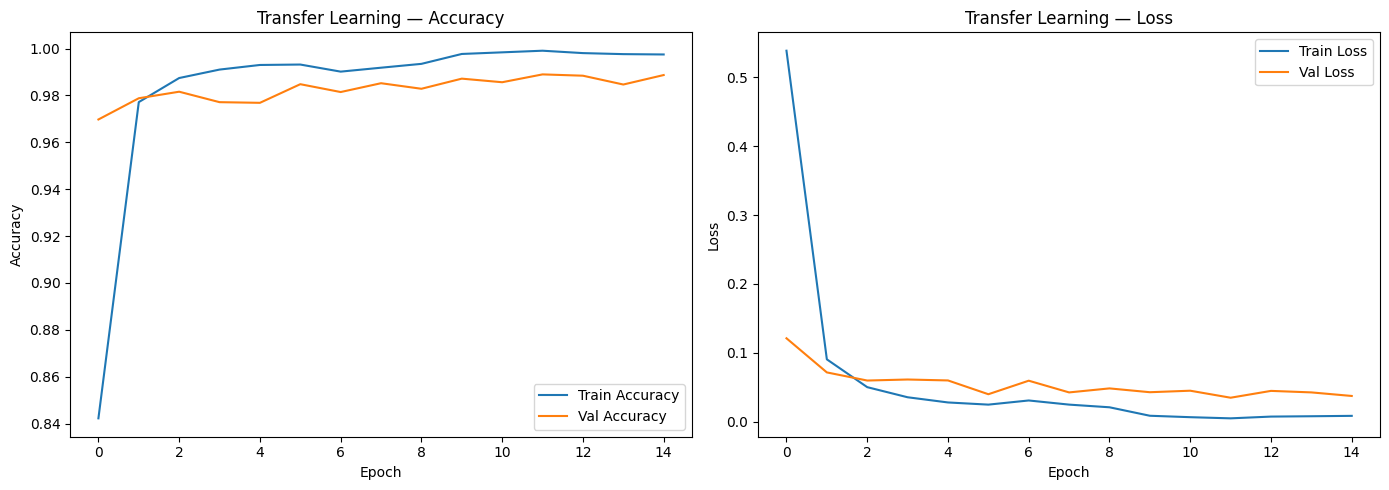

In [68]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tl_history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(tl_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Transfer Learning — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(tl_history.history['loss'],     label='Train Loss')
axes[1].plot(tl_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Transfer Learning — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [69]:
# Evaluation
tl_loss, tl_acc = tl_model.evaluate(test_images_tl, test_labels_ohe)
print(f'Transfer Learning Test Loss:     {tl_loss:.4f}')
print(f'Transfer Learning Test Accuracy: {tl_acc:.4f}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9890 - loss: 0.0342
Transfer Learning Test Loss:     0.0346
Transfer Learning Test Accuracy: 0.9890


225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step


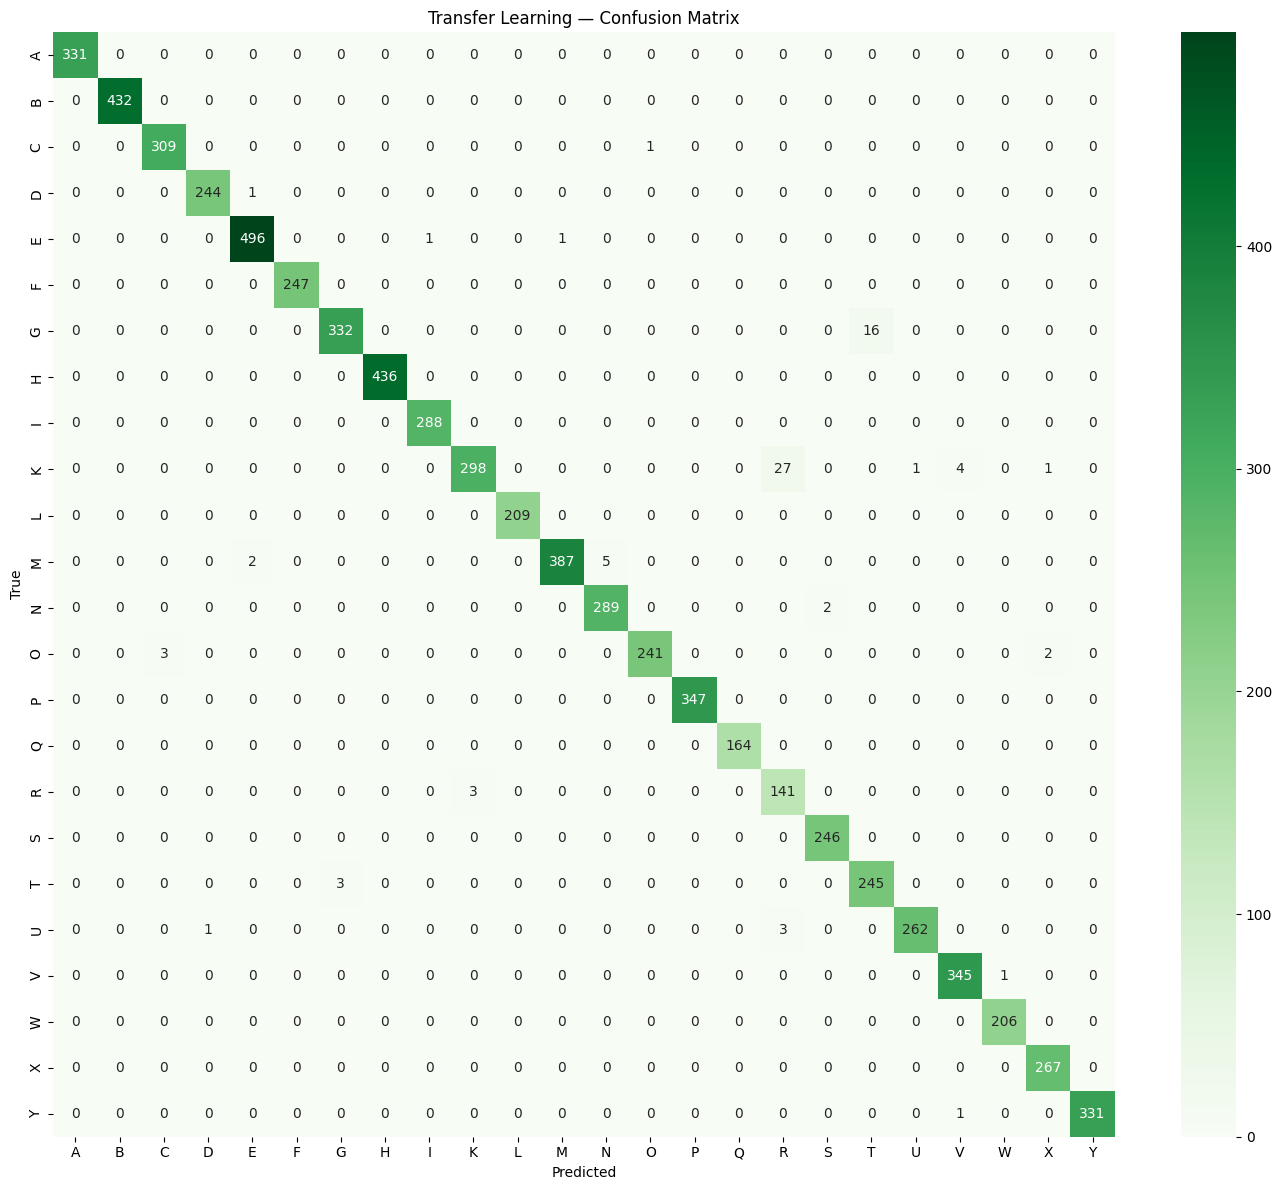

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       0.99      1.00      0.99       310
           D       1.00      1.00      1.00       245
           E       0.99      1.00      0.99       498
           F       1.00      1.00      1.00       247
           G       0.99      0.95      0.97       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       0.99      0.90      0.94       331
           L       1.00      1.00      1.00       209
           M       1.00      0.98      0.99       394
           N       0.98      0.99      0.99       291
           O       1.00      0.98      0.99       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.82      0.98      0.90       144
           S       0.99    

In [70]:
# Confusion Matrix
tl_predictions  = tl_model.predict(test_images_tl)
tl_pred_indices = np.argmax(tl_predictions, axis=1)
tl_y_pred       = lb.classes_[tl_pred_indices]

cm_tl = confusion_matrix(test_labels, tl_y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', xticklabels=letters, yticklabels=letters)
plt.title('Transfer Learning — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print(classification_report(test_labels, tl_y_pred, target_names=letters))

### Transfer Learning — Test Image Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


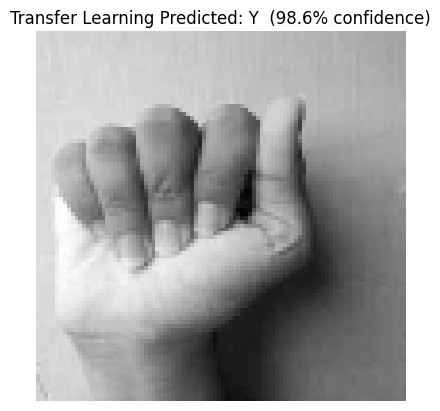

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


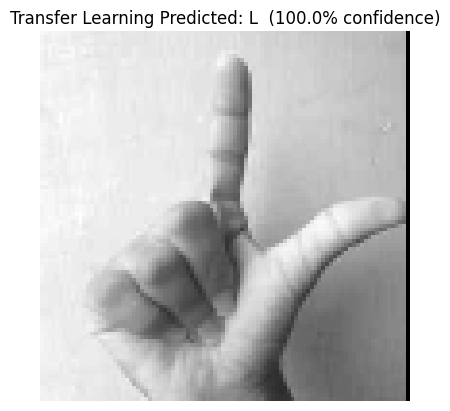

In [71]:
def predict_image_tl(img_path):
    img          = tf.io.read_file(img_path)
    img          = tf.image.decode_image(img, channels=1)
    img          = tf.image.resize(img, [IMG_SIZE_TL, IMG_SIZE_TL])
    img_array_tl = img.numpy() / 255.0
    img_array_tl = np.repeat(img_array_tl.reshape(1, IMG_SIZE_TL, IMG_SIZE_TL, 1), 3, axis=-1)
    pred         = tl_model.predict(img_array_tl)
    letter       = label_map[lb.classes_[np.argmax(pred)]]
    conf         = np.max(pred) * 100
    plt.imshow(img_array_tl[0, :, :, 0], cmap='gray')
    plt.title(f'Transfer Learning Predicted: {letter}  ({conf:.1f}% confidence)')
    plt.axis('off'); plt.show()

predict_image_tl('/kaggle/input/datasets/mimoali404/test-image/testproject.png')
predict_image_tl('/kaggle/input/datasets/mimoali404/test-image3/testproject2.png')

---
## 8. Models Comparison

### 8.1 Accuracy & Loss

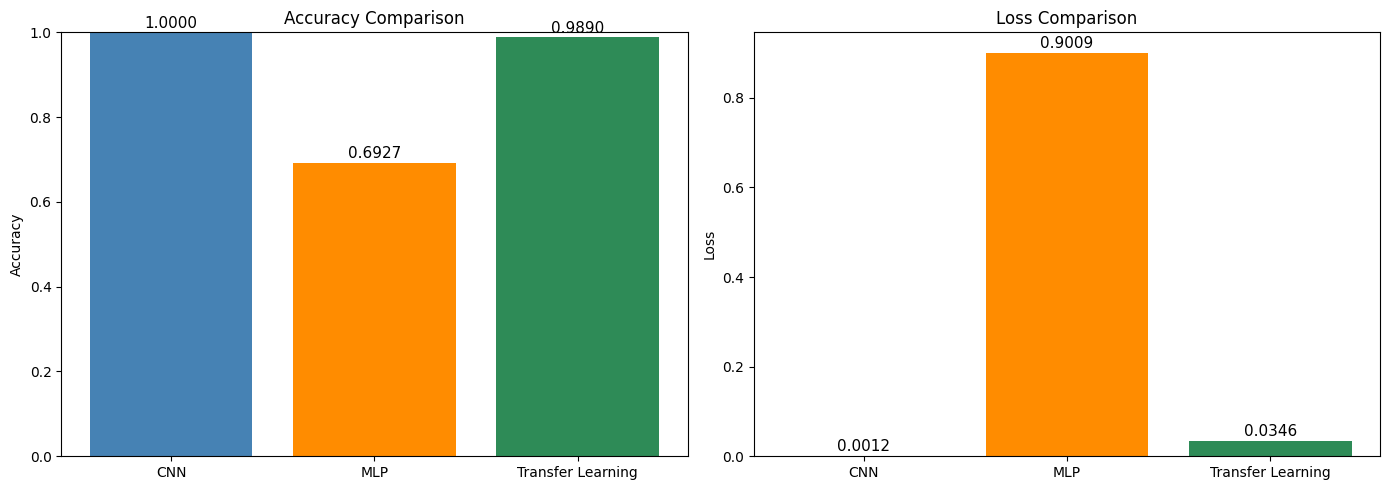

CNN Accuracy:               1.0000
MLP Accuracy:               0.6927
Transfer Learning Accuracy: 0.9890


In [72]:
model_names = ['CNN', 'MLP', 'Transfer Learning']
accuracies  = [cnn_acc, mlp_acc, tl_acc]
losses      = [cnn_loss, mlp_loss, tl_loss]
colors      = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_title('Accuracy Comparison'); axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=11)

bars2 = axes[1].bar(model_names, losses, color=colors)
axes[1].set_title('Loss Comparison'); axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout(); plt.show()

print(f'CNN Accuracy:               {cnn_acc:.4f}')
print(f'MLP Accuracy:               {mlp_acc:.4f}')
print(f'Transfer Learning Accuracy: {tl_acc:.4f}')


### 8.2 Full Metrics — Precision, Recall, F1-Score

In [73]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Get predictions for all models
cnn_y_pred = lb.classes_[np.argmax(model.predict(test_images), axis=1)]
mlp_y_pred = lb.classes_[np.argmax(mlp_model.predict(test_images), axis=1)]
tl_y_pred  = lb.classes_[np.argmax(tl_model.predict(test_images_tl), axis=1)]

# Compute metrics
def get_metrics(y_true, y_pred):
    return {
        'Accuracy'  : np.mean(y_true == y_pred),
        'Precision' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score'  : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

cnn_metrics = get_metrics(test_labels, cnn_y_pred)
mlp_metrics = get_metrics(test_labels, mlp_y_pred)
tl_metrics  = get_metrics(test_labels, tl_y_pred)

# Summary table
metrics_df = pd.DataFrame({
    'CNN'               : cnn_metrics,
    'MLP'               : mlp_metrics,
    'Transfer Learning' : tl_metrics,
}).T.round(4)

print(metrics_df.to_string())

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
                   Accuracy  Precision  Recall  F1-Score
CNN                  1.0000     1.0000  1.0000    1.0000
MLP                  0.6927     0.7107  0.6927    0.6914
Transfer Learning    0.9890     0.9897  0.9890    0.9891


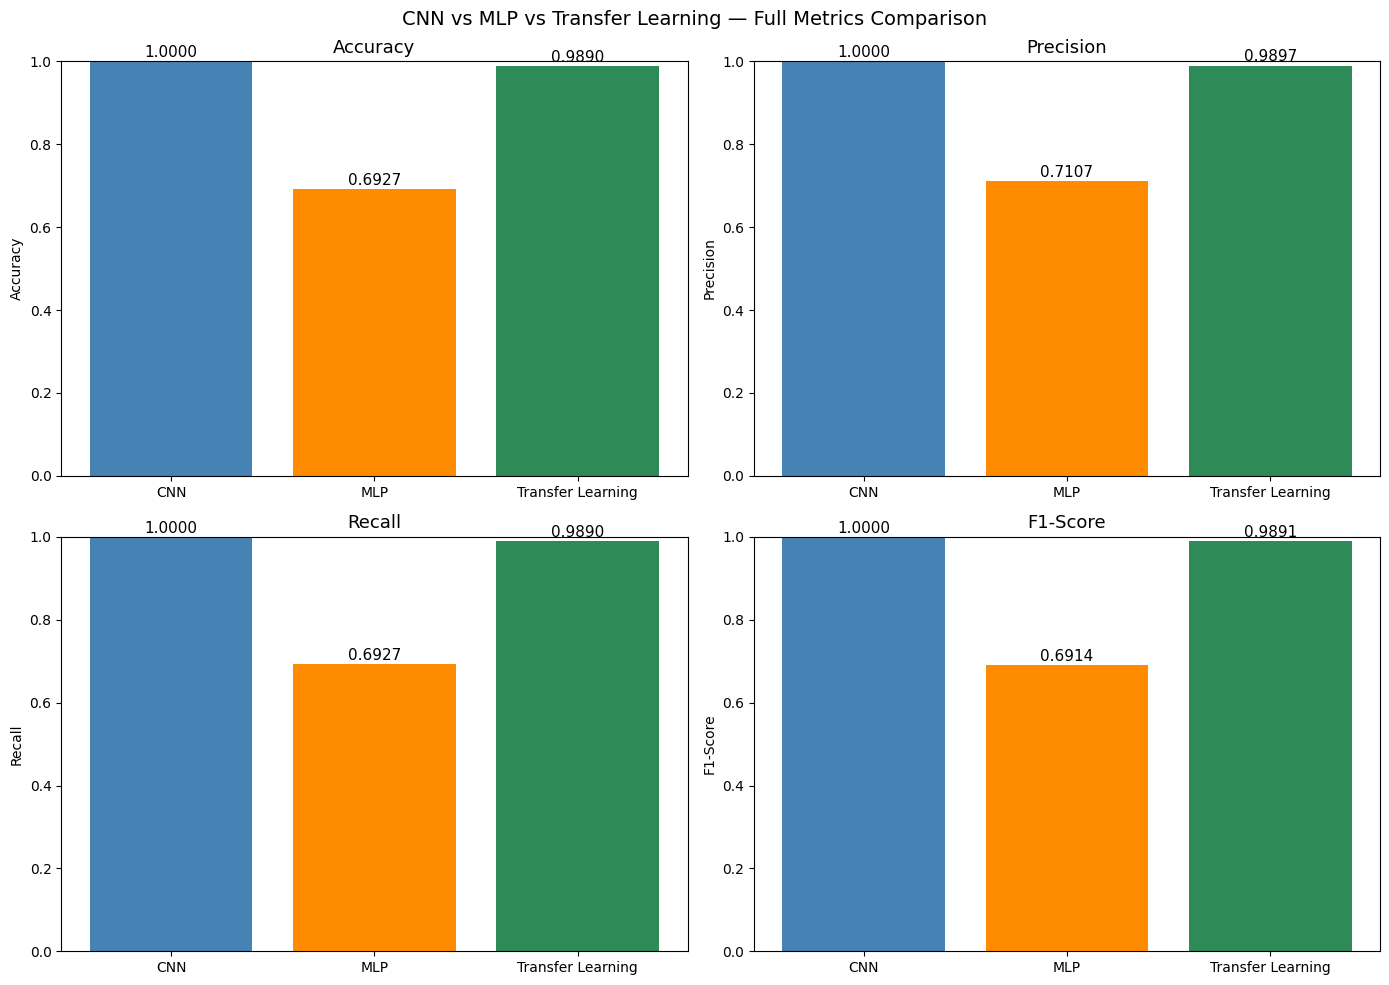

In [74]:
# Bar charts for each metric
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    values = [cnn_metrics[metric], mlp_metrics[metric], tl_metrics[metric]]
    bars   = axes[i].bar(model_names, values, color=colors)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=11)

plt.suptitle('CNN vs MLP vs Transfer Learning — Full Metrics Comparison', fontsize=14)
plt.tight_layout(); plt.show()

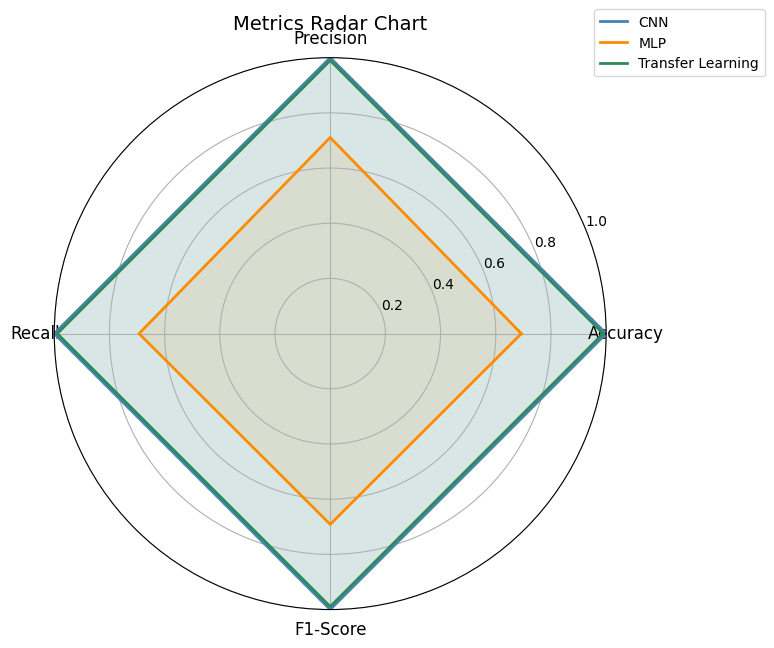

In [75]:
# Radar Chart
categories = metric_names
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for metrics, name, color in zip(
    [cnn_metrics, mlp_metrics, tl_metrics],
    model_names, colors
):
    values  = [metrics[m] for m in categories] + [metrics[categories[0]]]
    ax.plot(angles, values, color=color, linewidth=2, label=name)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Metrics Radar Chart', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()